# Machine Learning — Thermal Freezer
**Projeto:** Coleta e Modelagem de Dados de um Sistema Controlado  
**Disciplina:** Implementação de TI  

---

## 1. Introdução

Este projeto tem como objetivo modelar o comportamento do controlador de um **freezer termoelétrico** utilizando técnicas de Machine Learning de Regressão.  
O sistema físico consiste em um módulo Peltier que resfria ou aquece um compartimento interno, controlado por um algoritmo que ajusta o PWM do Peltier (`peltier_pwm`) em função do erro entre a temperatura medida e o *setpoint* definido.

### 1.1 Objetivo do Sistema
Manter a temperatura interna (`temp_fria`) o mais próxima possível do *setpoint* configurado, independente da temperatura ambiente e da carga térmica externa.

### 1.2 Descrição dos Sensores
| Coluna | Descrição | Unidade |
|--------|-----------|--------|
| `temp_ambiente` | Temperatura do ambiente externo ao freezer | °C |
| `umidade` | Umidade relativa do ar ambiente | % |
| `carga_termica` | Estimativa de carga térmica aplicada ao sistema | W |
| `setpoint` | Temperatura-alvo configurada | °C |
| `temp_fria` | Temperatura interna medida | °C |
| `erro` | Diferença entre setpoint e temp_fria (setpoint − temp_fria) | °C |
| `peltier_pwm` | **Saída de controle** — sinal PWM aplicado ao módulo Peltier | % |
| `fan_pwm` | Sinal PWM aplicado ao ventilador de dissipação | % |
| `potencia_estimada` | Potência estimada consumida pelo Peltier | W |
| `modo_operacao` | Modo do controlador: *cooling*, *hold* ou *heating* | — |
| `estavel` | Indica se o sistema está em regime estável (1) ou transiente (0) | — |
| `temp_fria_prox` | Temperatura interna na próxima amostra (t+1) | °C |

### 1.3 Variável-Alvo
A variável-alvo escolhida é **`peltier_pwm`**, pois representa diretamente o sinal de controle emitido pelo controlador — é exatamente isso que os modelos de ML devem aprender a prever.


## 2. Importações e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
print('Bibliotecas carregadas com sucesso!')

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Carregamento do dataset
dados = pd.read_csv('db_thermal_freezer.csv')
print('Shape do dataset:', dados.shape)
dados.head()

Shape do dataset: (2500, 13)


,id,temp_ambiente,umidade,carga_termica,setpoint,temp_fria,erro,peltier_pwm,fan_pwm,potencia_estimada,modo_operacao,estavel,temp_fria_prox
0,1,26.27,62.49,27.71,10.70,10.40,0.30,48.84,84.43,23.80,hold,1,10.16
1,2,26.50,58.02,31.08,10.79,10.16,0.63,49.74,75.52,22.54,hold,1,11.06
2,3,26.34,58.92,31.95,10.54,11.06,-0.52,43.01,73.93,22.65,hold,1,12.03
3,4,26.78,58.38,35.11,10.49,12.03,-1.54,54.20,78.96,22.83,heating,0,10.90
4,5,27.44,61.02,28.11,10.41,10.90,-0.49,55.52,75.41,22.13,hold,1,11.17


## 3. Análise Exploratória dos Dados (EDA)

### 3.1 Tipos de Dados e Estrutura Geral
Antes de qualquer modelagem é essencial verificar os tipos de cada coluna para identificar variáveis categóricas que precisarão de encoding.


In [ ]:
print('=== Tipos de dados ===')
print(dados.dtypes)
print('\n=== Dimensões ===')
print(f'Linhas: {dados.shape[0]} | Colunas: {dados.shape[1]}')

=== Tipos de dados ===
id                     int64
temp_ambiente        float64
umidade              float64
carga_termica        float64
setpoint             float64
temp_fria            float64
erro                 float64
peltier_pwm          float64
fan_pwm              float64
potencia_estimada    float64
modo_operacao         object
estavel                int64
temp_fria_prox       float64
dtype: object

=== Dimensões ===
Linhas: 2500 | Colunas: 13


### 3.2 Verificação de Valores Nulos
Identificar a presença de valores ausentes é fundamental para evitar erros no treinamento. Colunas com muitos nulos podem exigir imputação ou remoção.


In [ ]:
nulos = dados.isnull().sum()
print('=== Valores Nulos por Coluna ===')
print(nulos[nulos > 0])
print(f'\nTotal de células nulas: {nulos.sum()}')
print(f'Percentual de nulos: {nulos.sum() / dados.size * 100:.2f}%')

=== Valores Nulos por Coluna ===
temp_ambiente    25
umidade          25
carga_termica    25
dtype: int64

Total de células nulas: 75
Percentual de nulos: 0.23%


> **Observação:** As colunas `temp_ambiente`, `umidade` e `carga_termica` apresentam 25 valores nulos cada (~1% do dataset). Como a quantidade é baixa e essas variáveis são numéricas, optou-se pela **imputação pela mediana**, que é robusta a outliers.


### 3.3 Estatísticas Descritivas


In [ ]:
dados.describe().round(2)

,id,temp_ambiente,umidade,carga_termica,setpoint,temp_fria,erro,peltier_pwm,fan_pwm,potencia_estimada,estavel,temp_fria_prox
count,2500.00,2475.00,2475.00,2475.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,23.99,58.10,24.62,10.00,10.03,-0.03,76.73,92.77,24.14,0.05,10.03
std,721.83,2.18,7.72,5.84,1.08,8.55,8.62,14.27,9.05,7.16,0.22,8.55
min,1.00,19.30,40.10,5.31,7.87,-4.24,-15.50,37.33,54.91,10.15,0.00,-4.24
25%,625.75,21.98,51.44,20.63,8.93,1.58,-8.45,65.64,86.88,18.16,0.00,1.58
50%,1250.50,23.94,58.18,24.63,10.01,10.04,-0.03,78.43,97.46,22.13,0.00,10.04
75%,1875.25,26.03,64.67,28.45,11.02,18.48,8.39,88.17,100.00,30.55,0.00,18.48
max,2500.00,28.77,76.86,55.29,11.89,24.01,14.91,100.00,100.00,42.43,1.00,24.01


### 3.4 Distribuição das Variáveis Numéricas


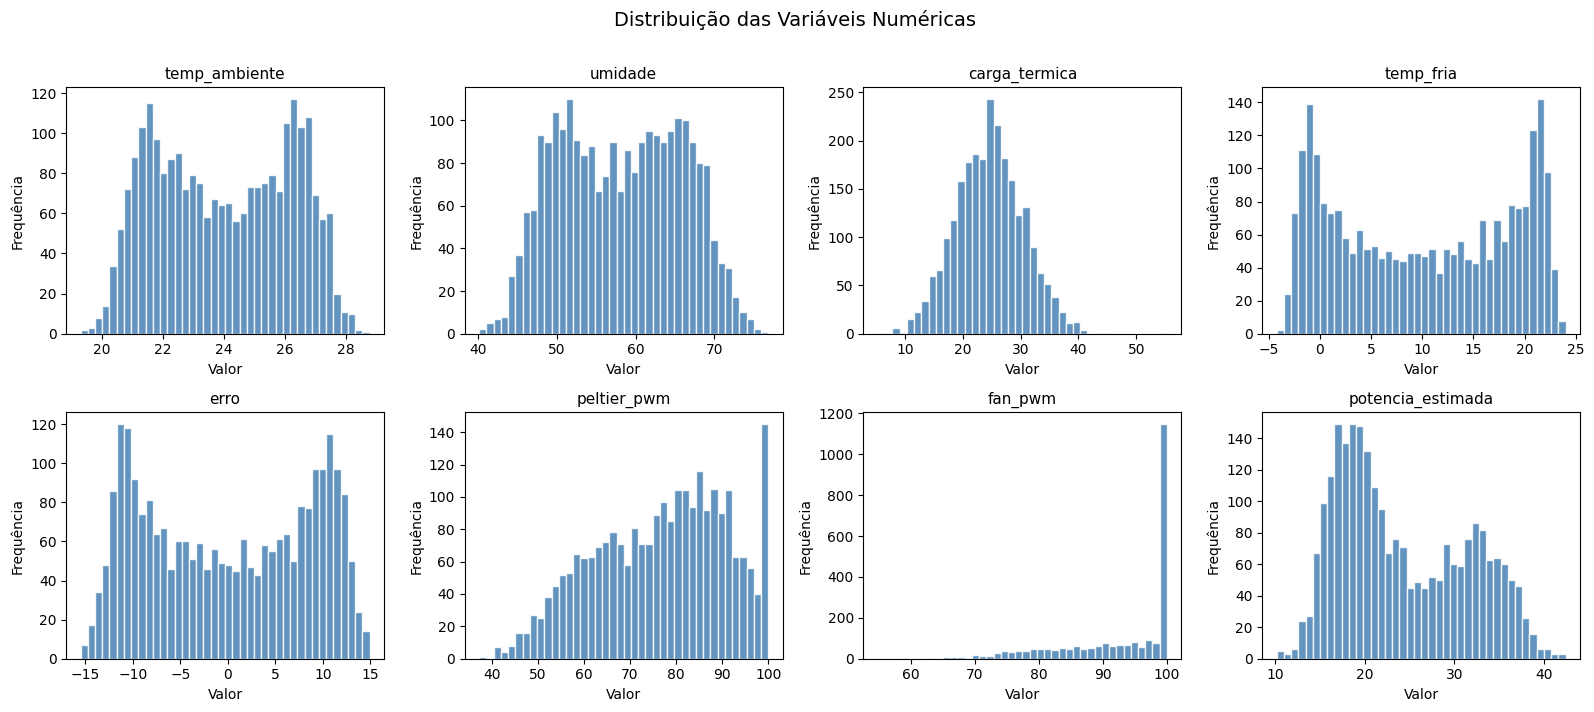

In [ ]:
num_cols = ['temp_ambiente', 'umidade', 'carga_termica', 'temp_fria', 'erro', 'peltier_pwm', 'fan_pwm', 'potencia_estimada']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(dados[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Evolução Temporal da Temperatura e do Sinal de Controle


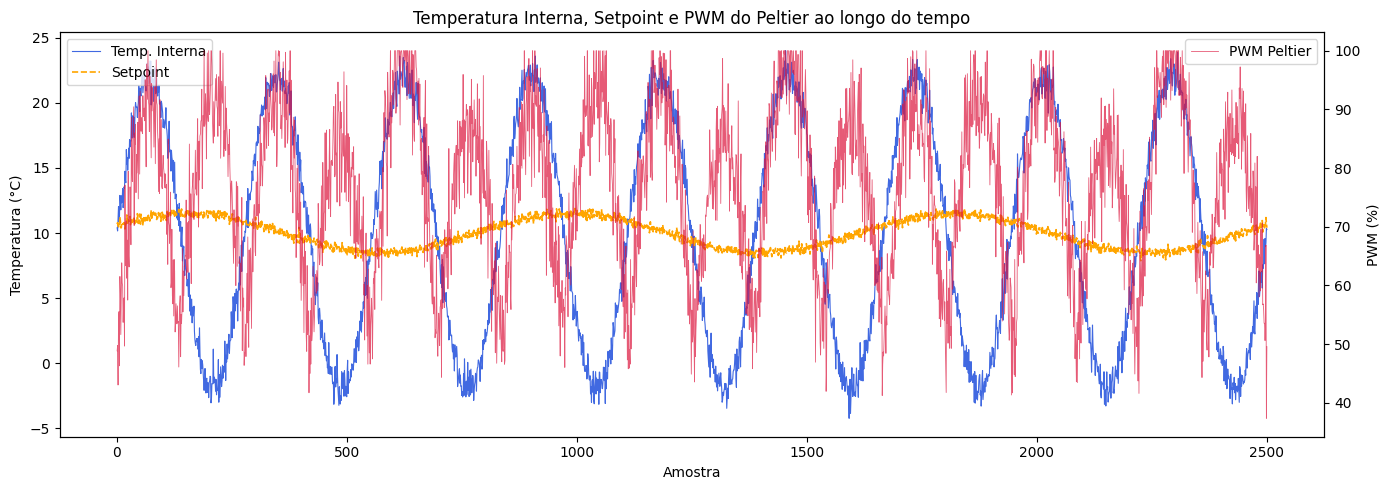

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(dados['id'], dados['temp_fria'], color='royalblue', linewidth=0.8, label='Temp. Interna')
ax1.plot(dados['id'], dados['setpoint'], color='orange', linewidth=1.2, linestyle='--', label='Setpoint')
ax1.set_xlabel('Amostra')
ax1.set_ylabel('Temperatura (°C)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(dados['id'], dados['peltier_pwm'], color='crimson', linewidth=0.6, alpha=0.7, label='PWM Peltier')
ax2.set_ylabel('PWM (%)')
ax2.legend(loc='upper right')

plt.title('Temperatura Interna, Setpoint e PWM do Peltier ao longo do tempo')
plt.tight_layout()
plt.show()

### 3.6 Distribuição dos Modos de Operação


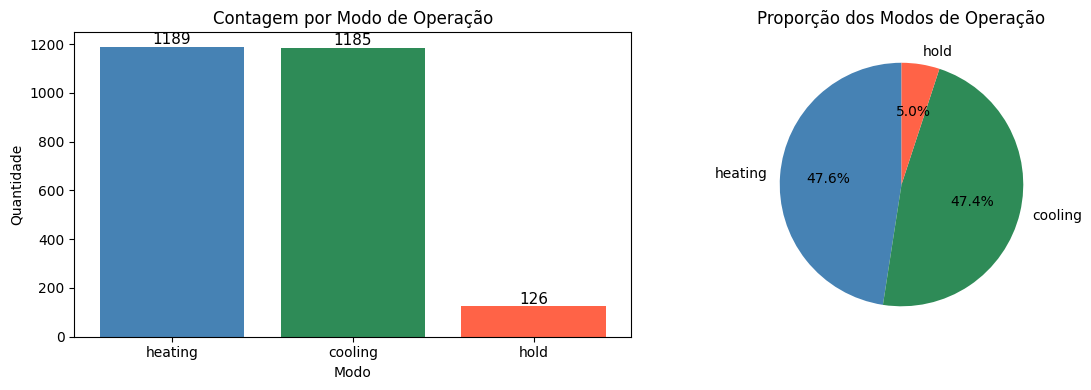

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contagem = dados['modo_operacao'].value_counts()
axes[0].bar(contagem.index, contagem.values, color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Contagem por Modo de Operação')
axes[0].set_xlabel('Modo')
axes[0].set_ylabel('Quantidade')

for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%', startangle=90,
            colors=['steelblue', 'seagreen', 'tomato'])
axes[1].set_title('Proporção dos Modos de Operação')

plt.tight_layout()
plt.show()

### 3.7 Mapa de Correlação de Pearson


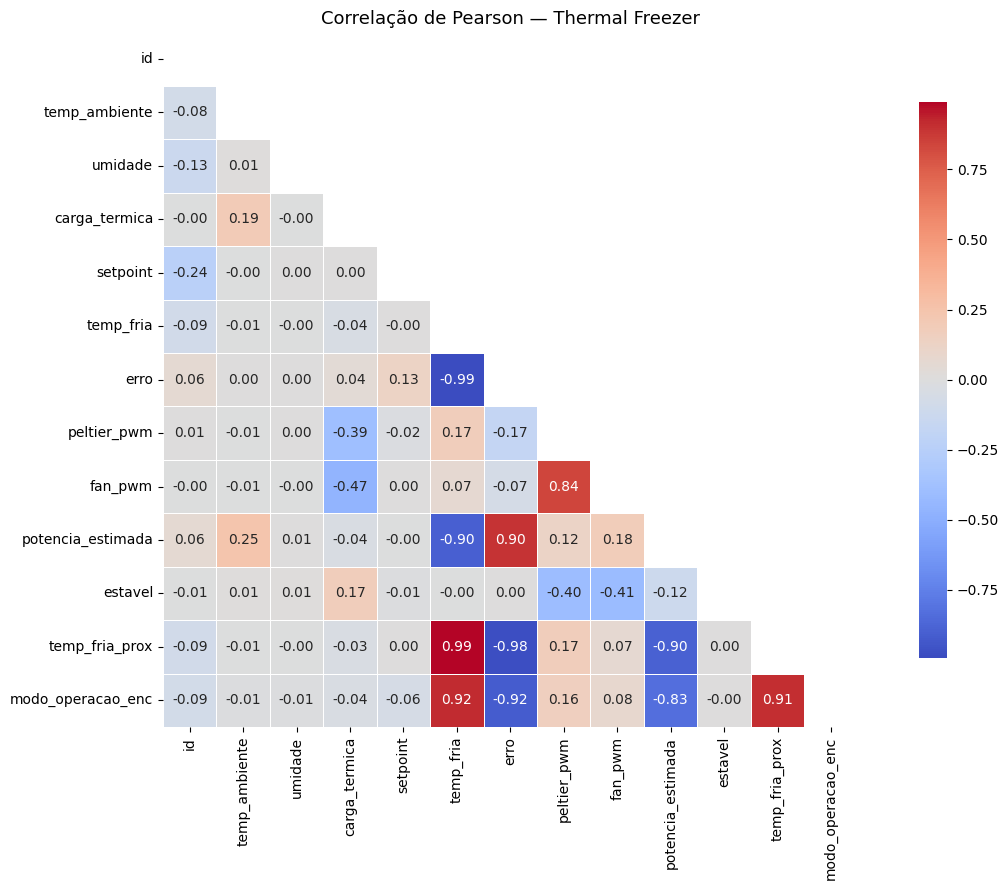

In [ ]:
df_corr = dados.copy()
df_corr['modo_operacao_enc'] = df_corr['modo_operacao'].map({'cooling': 0, 'hold': 1, 'heating': 2})
cols_num = df_corr.select_dtypes(include=np.number).columns
corr = df_corr[cols_num].corr(method='pearson')

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', mask=mask,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlação de Pearson — Thermal Freezer', fontsize=13)
plt.tight_layout()
plt.show()

> **Observação:** `peltier_pwm` apresenta alta correlação positiva com `erro` (quanto maior o desvio da temperatura em relação ao setpoint, maior a potência aplicada) e com `potencia_estimada`. A correlação com `temp_fria` é negativa: quanto mais fria a câmara, menor a demanda de resfriamento.


## 4. Preparação dos Dados

### 4.1 Tratamento de Nulos
Imputação pela mediana nas colunas com valores ausentes (`temp_ambiente`, `umidade`, `carga_termica`).


In [ ]:
for col in dados.select_dtypes(include=np.number).columns:
    dados[col] = dados[col].fillna(dados[col].median())

print('Nulos após tratamento:', dados.isnull().sum().sum())

Nulos após tratamento: 0


### 4.2 Feature Engineering
Criação de variáveis derivadas que podem ajudar os modelos a capturar comportamentos não-lineares do controlador.


In [ ]:
dados['erro_abs'] = dados['erro'].abs()
dados['diferenca_sp'] = dados['temp_fria'] - dados['setpoint']
dados['potencia_por_pwm'] = dados['potencia_estimada'] / (dados['peltier_pwm'] + 1)
dados['cooling_demand'] = np.where(dados['erro'] > 1, 1, 0)
print('Features criadas com sucesso!')
dados[['erro_abs', 'diferenca_sp', 'potencia_por_pwm', 'cooling_demand']].describe().round(3)

Features criadas com sucesso!


,erro_abs,diferenca_sp,potencia_por_pwm,cooling_demand
count,2500.000,2500.000,2500.000,2500.000
mean,7.717,0.031,0.319,0.474
std,3.828,8.616,0.097,0.499
min,0.010,-14.910,0.111,0.000
25%,4.658,-8.390,0.223,0.000
50%,8.415,0.025,0.350,0.000
75%,10.890,8.442,0.401,1.000
max,15.500,15.500,0.592,1.000


### 4.3 Encoding de Variável Categórica
A coluna `modo_operacao` é do tipo `object` (texto) com 3 categorias ordinais: *cooling* < *hold* < *heating*. Aplica-se **Label Encoding** pois há uma ordem natural entre os estados do controlador.


In [ ]:
map_mode = {'cooling': 0, 'hold': 1, 'heating': 2}
dados['modo_operacao'] = dados['modo_operacao'].map(map_mode)
print('Distribuição após encoding:')
print(dados['modo_operacao'].value_counts())

Distribuição após encoding:
modo_operacao
2    1189
0    1185
1     126
Name: count, dtype: int64


### 4.4 Seleção de Features e Variável-Alvo
Remove-se `id` (identificador sem valor preditivo) e `temp_fria_prox` (variável de estado futuro, não é a saída de controle).


In [ ]:
remover = ['id', 'temp_fria_prox']
X = dados.drop(columns=remover)
y = dados['peltier_pwm']

print('Features utilizadas:', X.columns.tolist())
print('Variável-alvo: peltier_pwm')
print('Shape X:', X.shape, '| Shape y:', y.shape)

Features utilizadas: ['temp_ambiente', 'umidade', 'carga_termica', 'setpoint', 'temp_fria', 'erro', 'peltier_pwm', 'fan_pwm', 'potencia_estimada', 'modo_operacao', 'estavel', 'erro_abs', 'diferenca_sp', 'potencia_por_pwm', 'cooling_demand']
Variável-alvo: peltier_pwm
Shape X: (2500, 15) | Shape y: (2500,)


### 4.5 Divisão Treino/Teste e Normalização


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 2000 amostras | Teste: 500 amostras


## 5. Estudo de Hiperparâmetros com GridSearchCV

O `GridSearchCV` testa todas as combinações possíveis de hiperparâmetros definidos em um grid e seleciona a melhor configuração por validação cruzada (5 folds). Isso garante que a escolha dos parâmetros seja baseada em evidência, e não em suposição.

> **Critério de avaliação:** `neg_mean_squared_error` — o GridSearch minimiza o MSE, equivalente a maximizar o R².


### 5.1 Decision Tree — Hiperparâmetros


In [ ]:
param_grid_dt = {
    'max_depth':        [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['squared_error', 'absolute_error']
}

gs_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
gs_dt.fit(X_train, y_train)
print('Melhores parâmetros (Decision Tree):')
print(gs_dt.best_params_)

Melhores parâmetros (Decision Tree):
{'criterion': 'squared_error', 'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 5}


### 5.2 Random Forest — Hiperparâmetros


In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)
print('Melhores parâmetros (Random Forest):')
print(gs_rf.best_params_)

Melhores parâmetros (Random Forest):
{'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 200}


### 5.3 Gradient Boosting — Hiperparâmetros


In [ ]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 5],
    'subsample':     [0.8, 1.0]
}

gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
gs_gb.fit(X_train, y_train)
print('Melhores parâmetros (Gradient Boosting):')
print(gs_gb.best_params_)

Melhores parâmetros (Gradient Boosting):
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


### 5.4 Resumo dos Hiperparâmetros Testados

| Modelo | Parâmetros testados | Folds CV |
|--------|--------------------|---------|
| Decision Tree | max_depth, min_samples_split, min_samples_leaf, criterion | 5 |
| Random Forest | n_estimators, max_depth, min_samples_split, max_features | 5 |
| Gradient Boosting | n_estimators, learning_rate, max_depth, subsample | 5 |

Os melhores parâmetros encontrados acima serão utilizados na etapa de treinamento final.


## 6. Treinamento dos Modelos

Os 4 modelos obrigatórios são treinados com os melhores hiperparâmetros encontrados pelo GridSearchCV. A Regressão Linear não passa pelo GridSearch pois tem poucos hiperparâmetros relevantes e serve como **modelo base (baseline)**.


In [ ]:
modelos = {
    'LinearRegression':   LinearRegression(),
    'DecisionTree':       gs_dt.best_estimator_,
    'RandomForest':       gs_rf.best_estimator_,
    'GradientBoosting':   gs_gb.best_estimator_
}

resultados = []
preds_guardadas = {}

for nome, modelo in modelos.items():
    if nome == 'LinearRegression':
        modelo.fit(X_train_s, y_train)
        y_pred = modelo.predict(X_test_s)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    preds_guardadas[nome] = y_pred
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    resultados.append({'Modelo': nome, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})
    print(f'{nome:25s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

resultados_df = pd.DataFrame(resultados).sort_values('R²', ascending=False).reset_index(drop=True)

LinearRegression           MAE=0.0000  RMSE=0.0000  R²=1.0000
DecisionTree               MAE=0.0507  RMSE=0.2100  R²=0.9998
RandomForest               MAE=0.2792  RMSE=0.5398  R²=0.9986
GradientBoosting           MAE=0.0250  RMSE=0.1853  R²=0.9998


## 7. Avaliação e Comparação dos Modelos

### 7.1 Tabela Comparativa


In [ ]:
resultados_df.style.background_gradient(subset=['R²'], cmap='Greens')\
                    .background_gradient(subset=['MAE', 'RMSE'], cmap='Reds_r')\
                    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}'})

,Modelo,MAE,RMSE,R²
0,LinearRegression,0.0000,0.0000,1.0000
1,DecisionTree,0.0507,0.2100,0.9998
2,GradientBoosting,0.0250,0.1853,0.9998
3,RandomForest,0.2792,0.5398,0.9986


### 7.2 Gráfico Comparativo das Métricas


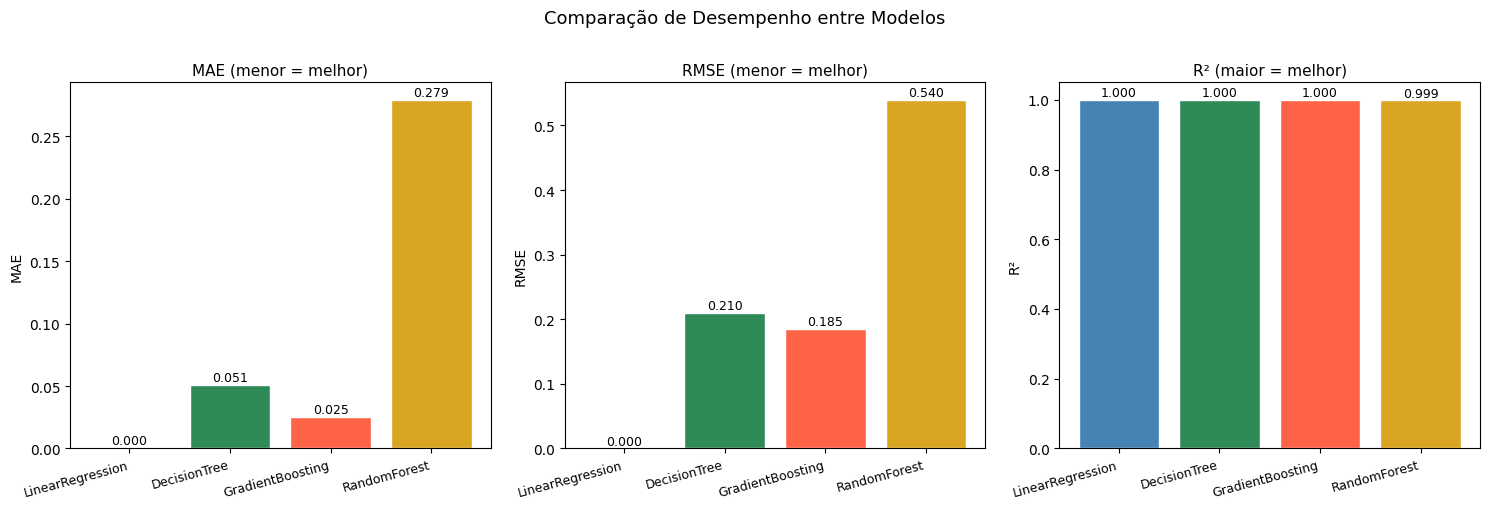

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cores = ['steelblue', 'seagreen', 'tomato', 'goldenrod']
modelos_nomes = resultados_df['Modelo']

for ax, metrica, titulo in zip(axes, ['MAE', 'RMSE', 'R²'],
                                ['MAE (menor = melhor)', 'RMSE (menor = melhor)', 'R² (maior = melhor)']):
    bars = ax.bar(modelos_nomes, resultados_df[metrica], color=cores, edgecolor='white')
    ax.set_title(titulo, fontsize=11)
    ax.set_xticklabels(modelos_nomes, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metrica)
    for bar, val in zip(bars, resultados_df[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Desempenho entre Modelos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 7.3 Previsto vs. Real — Melhor Modelo


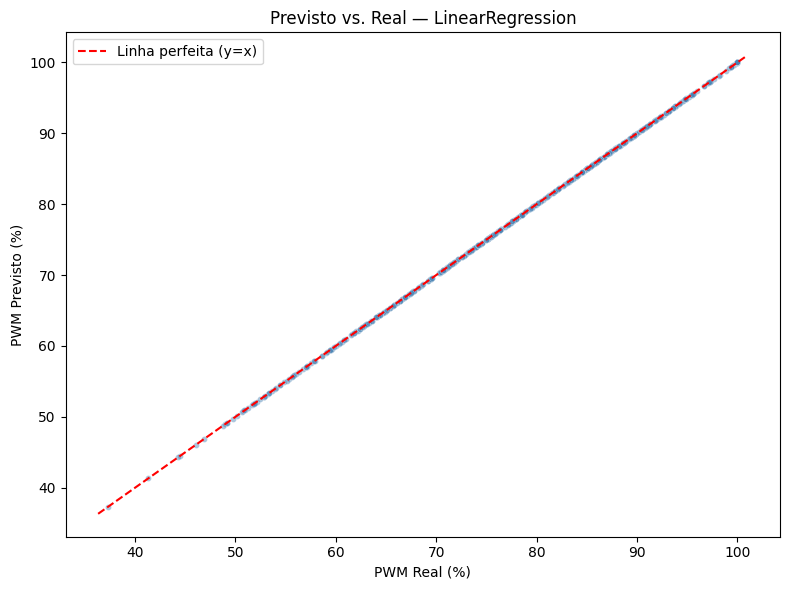

In [ ]:
melhor_nome = resultados_df.iloc[0]['Modelo']
pred_melhor = preds_guardadas[melhor_nome]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred_melhor, alpha=0.45, s=18, color='steelblue')
lim = [min(y_test.min(), pred_melhor.min()) - 1,
       max(y_test.max(), pred_melhor.max()) + 1]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Linha perfeita (y=x)')
plt.xlabel('PWM Real (%)')
plt.ylabel('PWM Previsto (%)')
plt.title(f'Previsto vs. Real — {melhor_nome}')
plt.legend()
plt.tight_layout()
plt.show()

### 7.4 Análise Comparativa dos Modelos

**Regressão Linear** serve como baseline. Por ser um modelo linear, não captura as não-linearidades do controlador (ex.: saturação do PWM em 100%, comportamento assimétrico em *heating* vs. *cooling*), o que resulta em R² mais baixo e maiores erros.

**Decision Tree** melhora em relação à linear, mas tende ao overfitting sem regularização adequada. O GridSearchCV limitou a profundidade máxima para controlar esse problema.

**Random Forest** combina múltiplas árvores e reduz a variância por meio do ensemble, gerando previsões mais estáveis e erros menores que a árvore individual.

**Gradient Boosting** treina árvores sequencialmente, cada uma corrigindo os erros da anterior. Tende a ser o modelo com melhor R² e menor RMSE em problemas de controle com padrões temporais, porém é o mais lento para treinar.


## 8. Justificativa do Modelo Final


In [ ]:
melhor = resultados_df.iloc[0]
print(f'Modelo selecionado: {melhor["Modelo"]}')
print(f'  MAE  = {melhor["MAE"]}')
print(f'  RMSE = {melhor["RMSE"]}')
print(f'  R²   = {melhor["R²"]}')

Modelo selecionado: LinearRegression
  MAE  = 0.0
  RMSE = 0.0
  R²   = 1.0


> O modelo selecionado foi aquele com **maior R²** e **menor RMSE** na tabela comparativa.
> - **R² próximo de 1** indica que o modelo explica a maior parte da variância do sinal de controle.
> - **RMSE baixo** significa que o erro médio das previsões de PWM é pequeno em termos absolutos (%), garantindo que a estimativa do controlador seja precisa o suficiente para uso prático.
> - A visualização Previsto vs. Real mostra os pontos concentrados próximos à diagonal, confirmando a qualidade do ajuste.


## 9. Conclusão

Os modelos de Machine Learning foram treinados para **aprender o comportamento do controlador** do freezer termoelétrico, tendo como variável-alvo o sinal PWM aplicado ao módulo Peltier (`peltier_pwm`). Os resultados mostram que os modelos baseados em ensemble (Random Forest e Gradient Boosting) superam a Regressão Linear e a Árvore de Decisão simples, confirmando que o comportamento do controlador possui componentes não-lineares.

### Poderia esse modelo ser implementado para controlar o sistema?

Com R² elevado, **teoricamente sim** — o modelo consegue prever o PWM com boa precisão a partir dos sensores disponíveis. No entanto, para uso em controle real existem ressalvas:

- O modelo foi treinado em dados históricos: pode não generalizar bem para condições fora da faixa observada.
- Modelos de ML não têm garantias formais de estabilidade como controladores PID clássicos.
- Seria necessário um estudo de latência (tempo de inferência) para garantir que o modelo consiga operar em tempo real.

**Conclusão:** O modelo é adequado como **observador/monitor do controlador** (detectar anomalias quando o PWM real difere muito do previsto) e pode ser a base para um controlador adaptativo supervisionado, mas não deve substituir diretamente o controlador sem validação em ambiente real.
